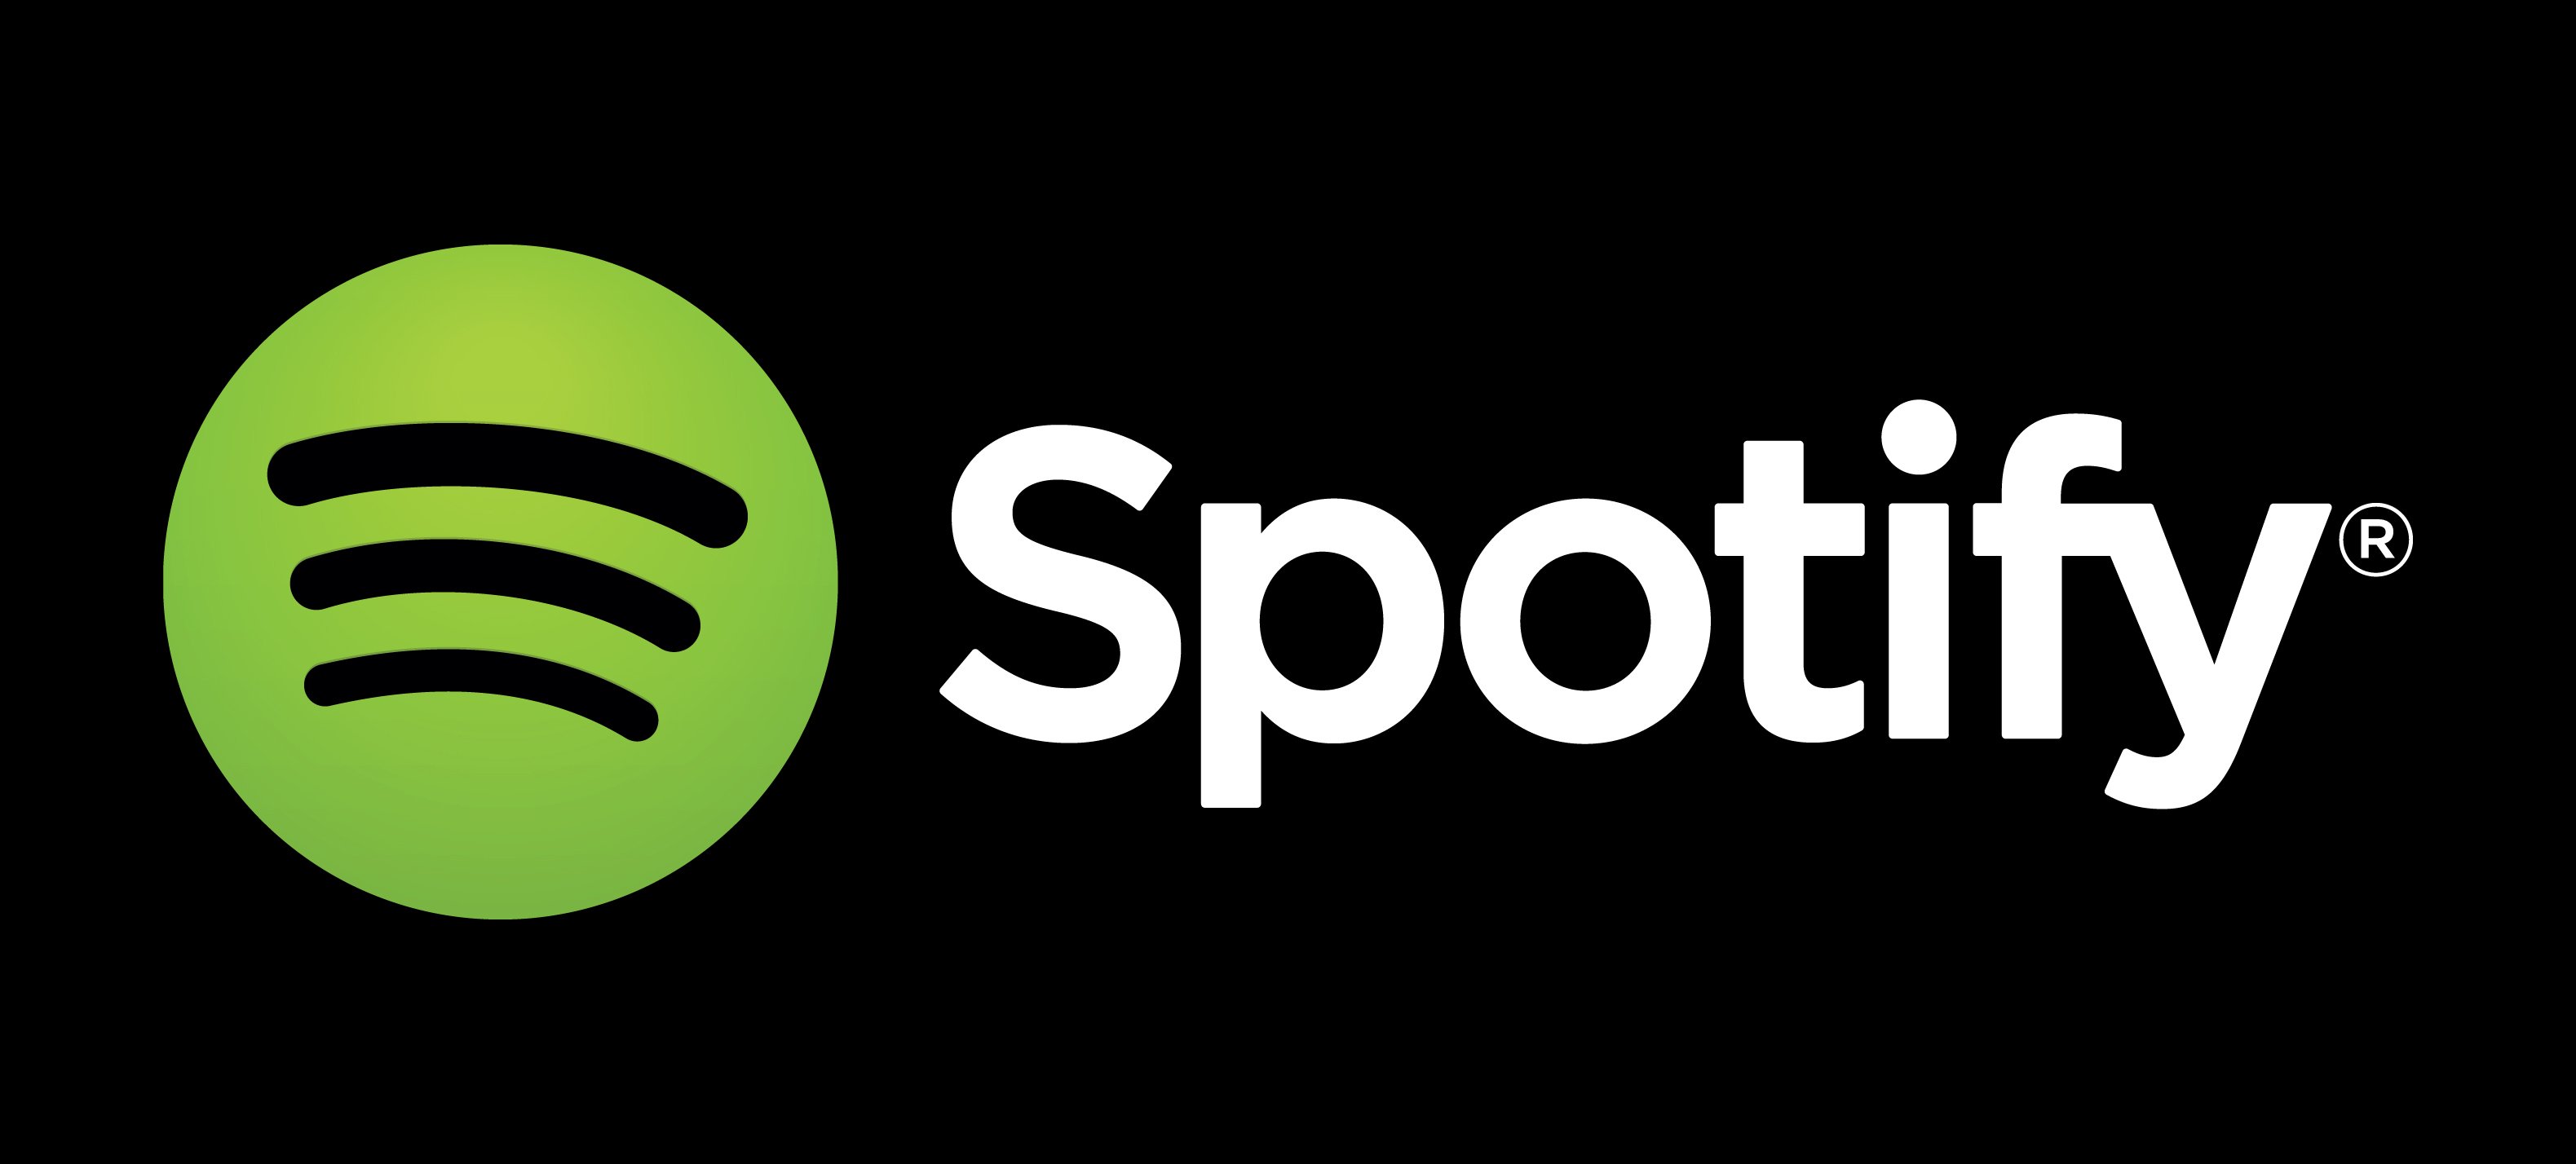

Spotify Music Genre Classificaton 🎧

In [273]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

Loading the Dataset ⏳

In [274]:
music_dataset = pd.read_csv('Spotify Dataset.csv')
music_dataset

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [213]:
music_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [214]:
music_dataset.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Preprocessing the Data 🛠️

In [215]:
print(music_dataset.isnull().sum())
print('\nthe number of null values is: ', music_dataset.isnull().sum().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

the number of null values is:  3


In [ ]:
print(music_dataset.nunique())
print('\nthe number of unique values is: ', music_dataset.nunique().sum())

Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46579
track_name           73601
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

the number of unique values is:  490089


In [217]:
print(music_dataset.duplicated())
print('\nthe number of duplicated values is: ', music_dataset.duplicated().sum())

0         False
1         False
2         False
3         False
4         False
          ...  
113995    False
113996    False
113997    False
113998    False
113999    False
Length: 114000, dtype: bool

the number of duplicated values is:  0


In [218]:
#now removing the useless features in the dataset
music_dataset.drop(['track_id', 'artists', 'album_name', 'track_name'], axis = 1, inplace = True)

In [219]:
music_dataset

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [220]:
music_dataset.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [221]:
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [222]:
original_column_names = music_dataset['track_genre']
original_column_names

0            acoustic
1            acoustic
2            acoustic
3            acoustic
4            acoustic
             ...     
113995    world-music
113996    world-music
113997    world-music
113998    world-music
113999    world-music
Name: track_genre, Length: 114000, dtype: object

In [223]:
#now label encoding
le = LabelEncoder()
music_dataset['explicit'] = le.fit_transform(music_dataset['explicit'])
music_dataset['track_genre'] = le.fit_transform(music_dataset['track_genre'])
music_dataset

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,0
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,0
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,0
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,0
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,113
113996,22,385000,0,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,113
113997,22,271466,0,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,113
113998,41,283893,0,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,113


Exploratory Data Analysis 🧐📊

<Figure size 1000x500 with 0 Axes>

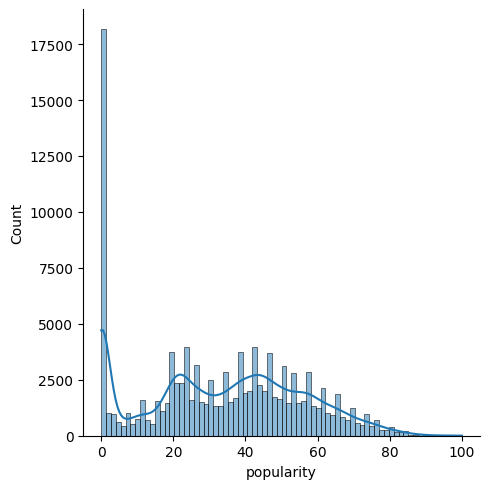

<Figure size 1000x500 with 0 Axes>

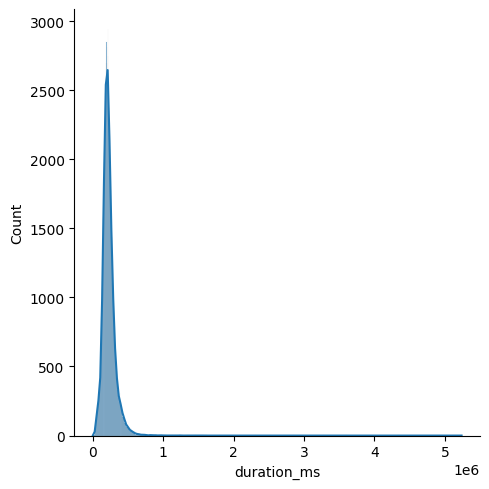

<Figure size 1000x500 with 0 Axes>

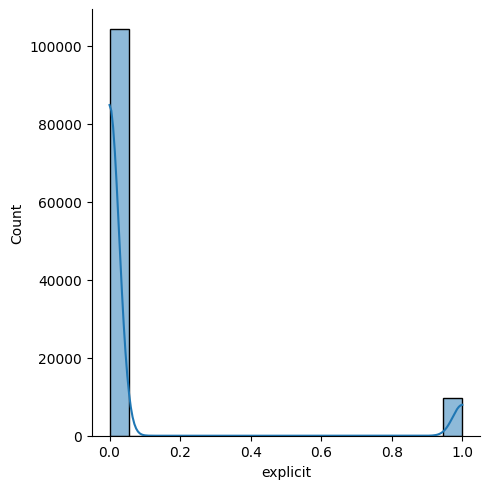

<Figure size 1000x500 with 0 Axes>

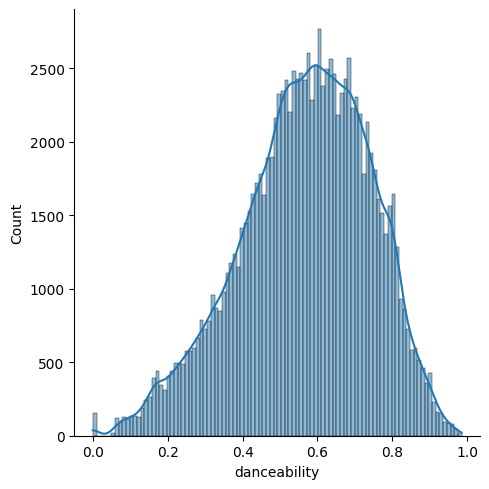

<Figure size 1000x500 with 0 Axes>

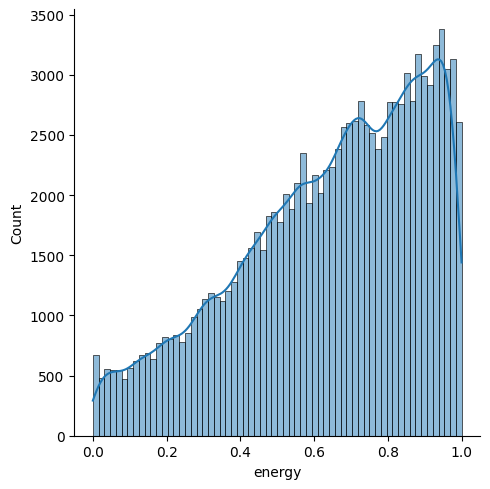

<Figure size 1000x500 with 0 Axes>

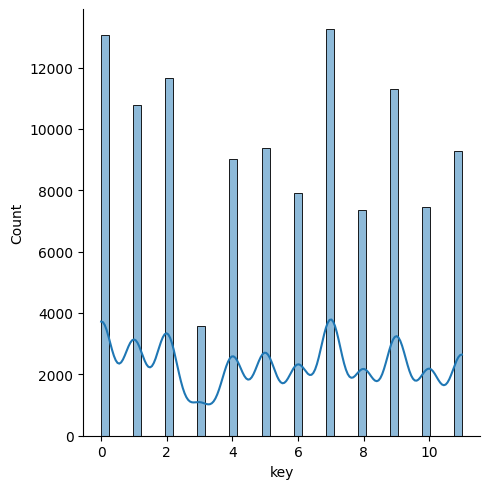

<Figure size 1000x500 with 0 Axes>

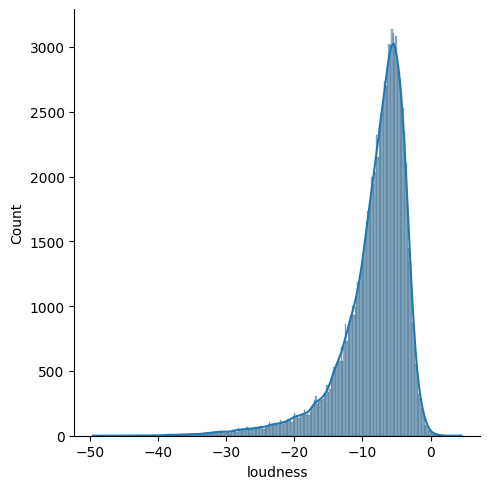

<Figure size 1000x500 with 0 Axes>

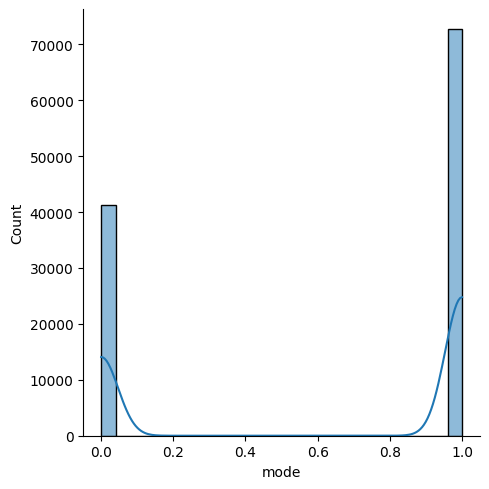

<Figure size 1000x500 with 0 Axes>

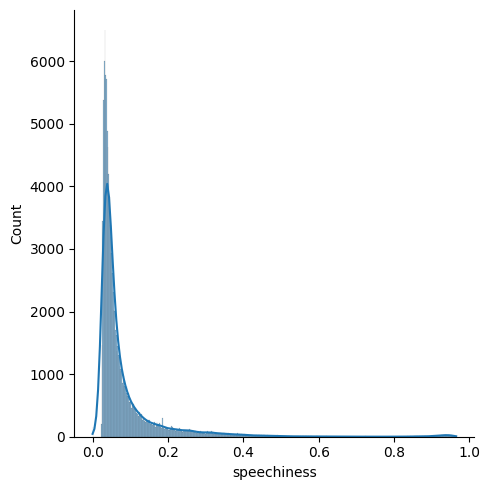

<Figure size 1000x500 with 0 Axes>

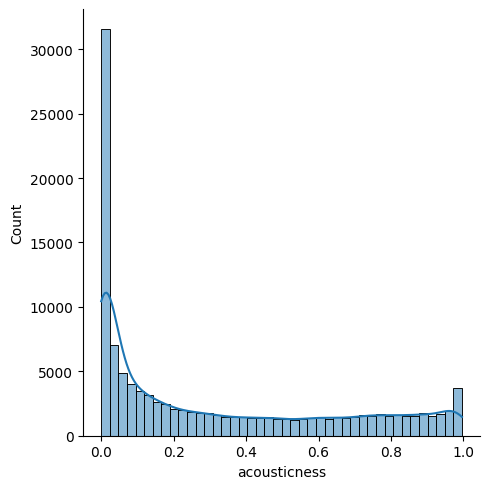

<Figure size 1000x500 with 0 Axes>

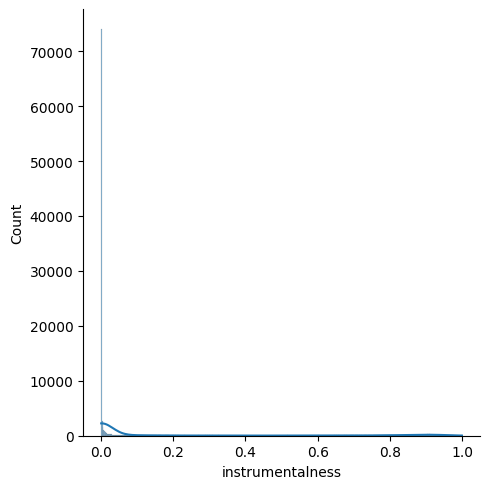

<Figure size 1000x500 with 0 Axes>

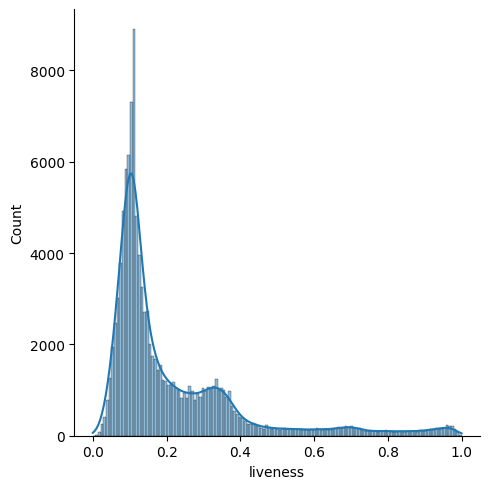

<Figure size 1000x500 with 0 Axes>

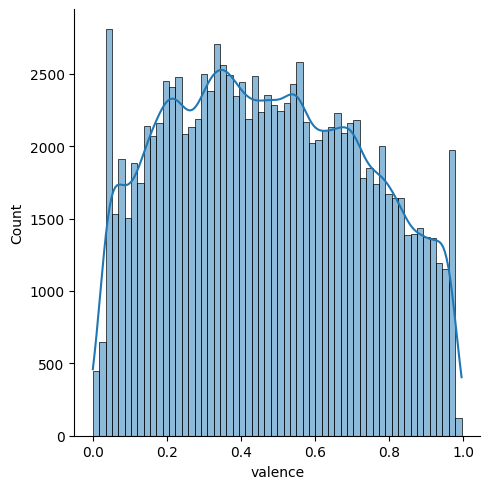

<Figure size 1000x500 with 0 Axes>

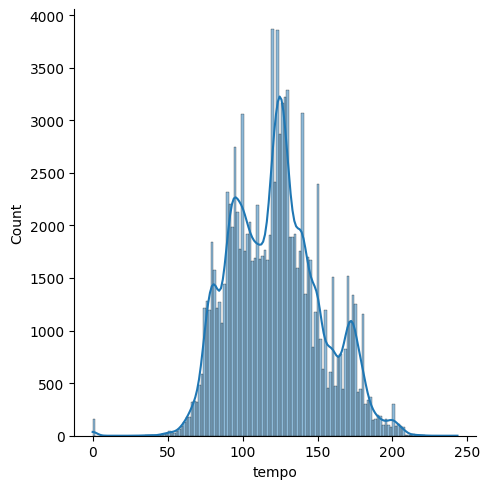

<Figure size 1000x500 with 0 Axes>

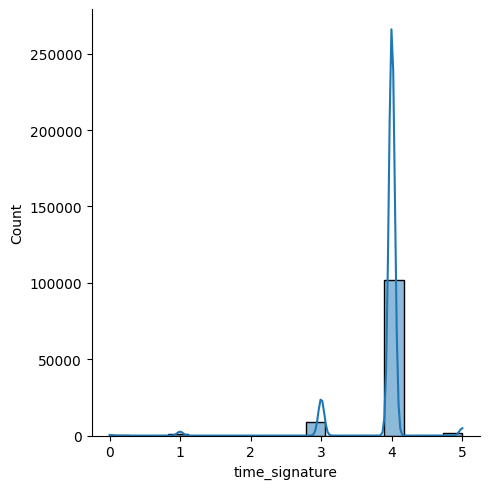

<Figure size 1000x500 with 0 Axes>

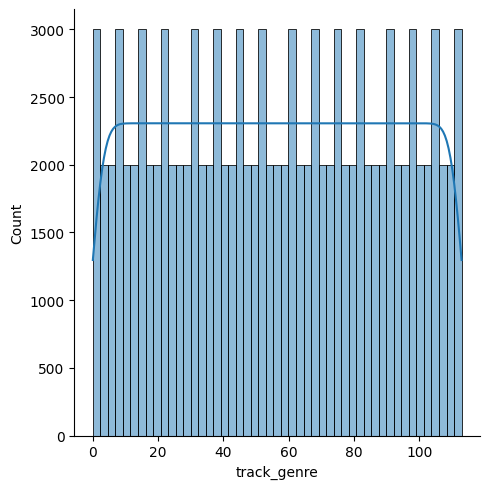

In [224]:
#histogram of dataset one by one
features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.displot(music_dataset[feature], kde = True)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

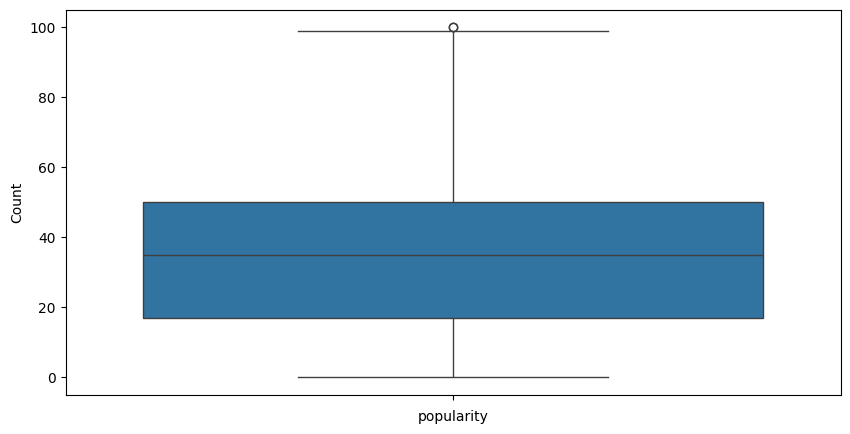

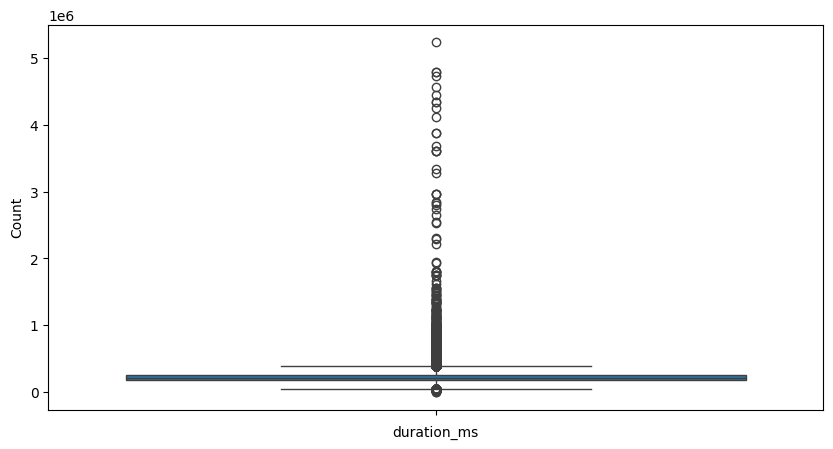

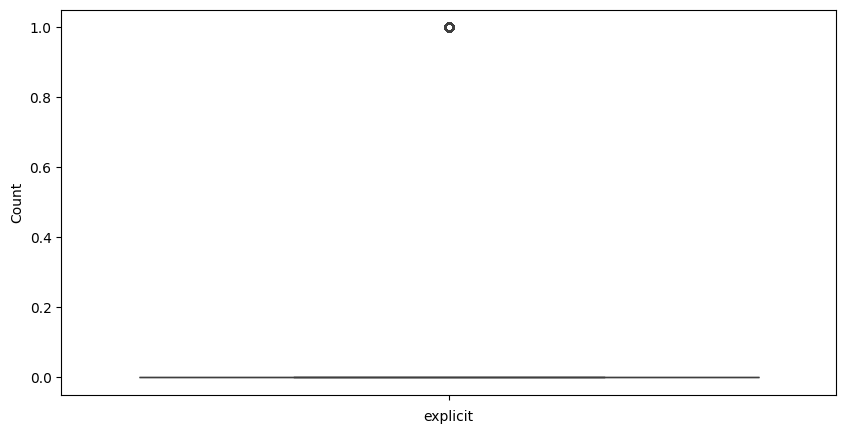

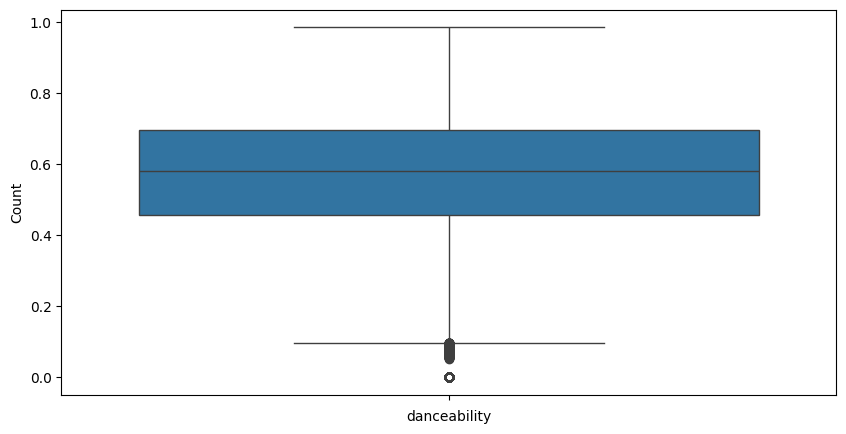

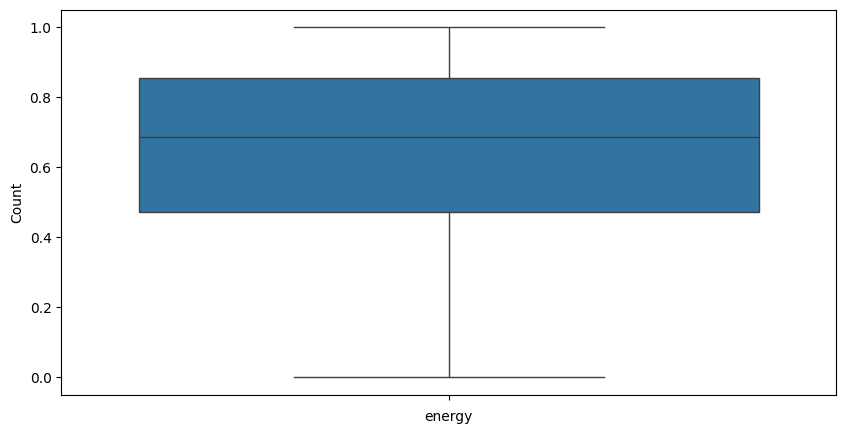

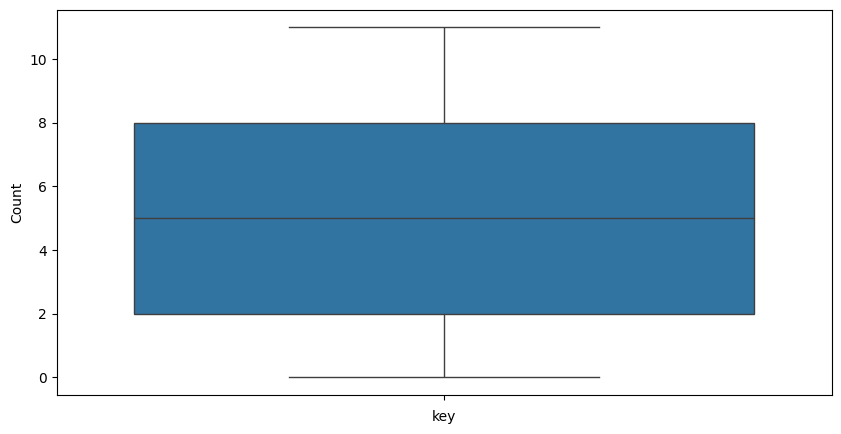

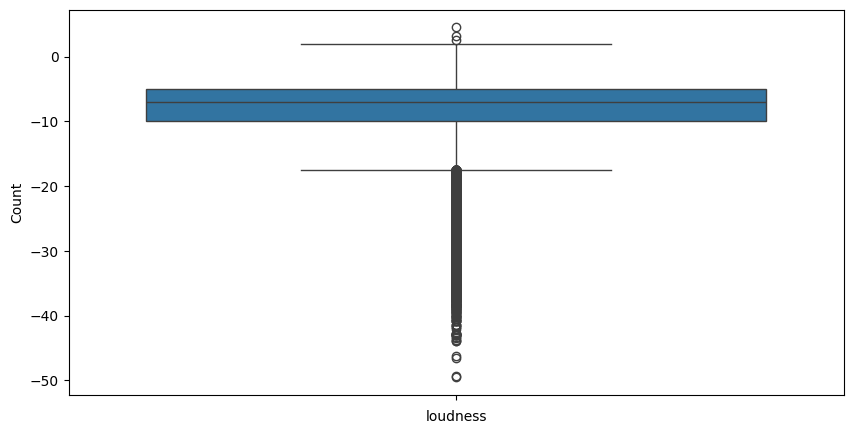

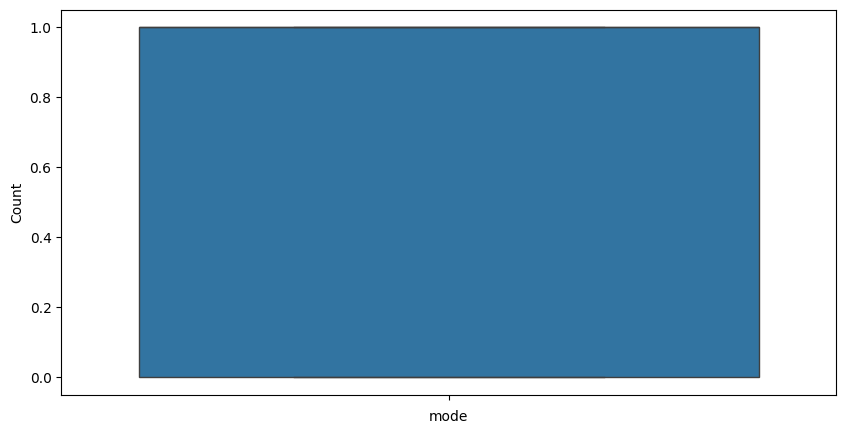

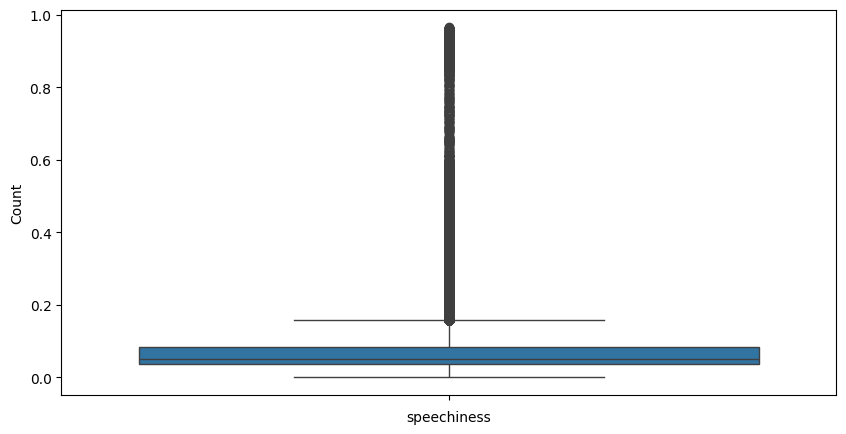

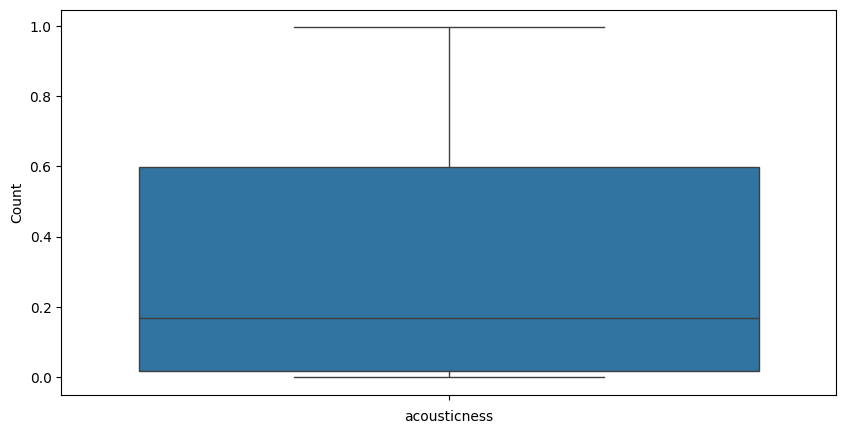

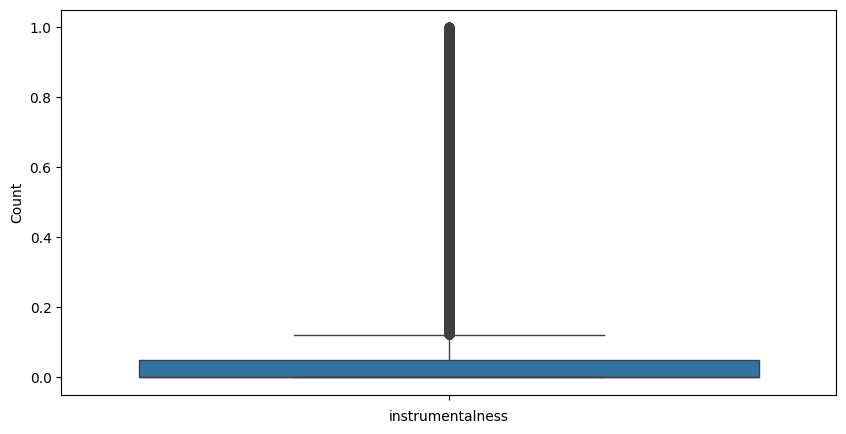

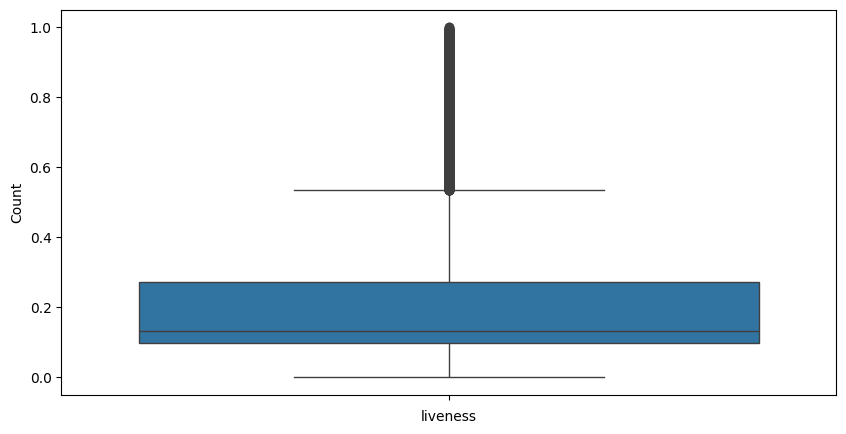

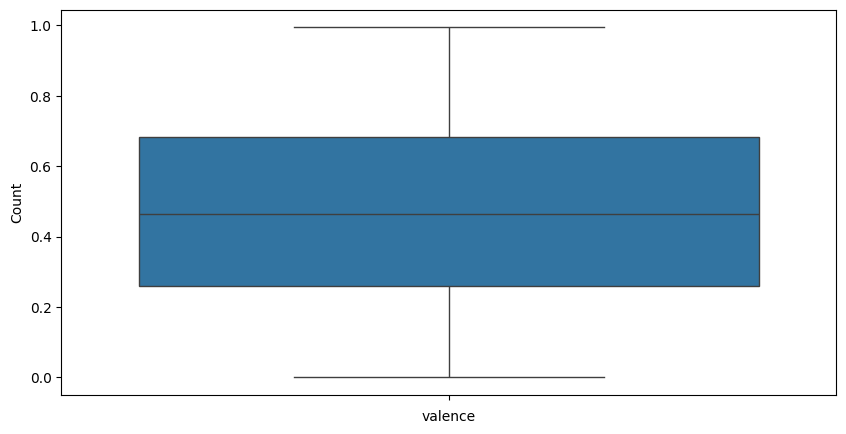

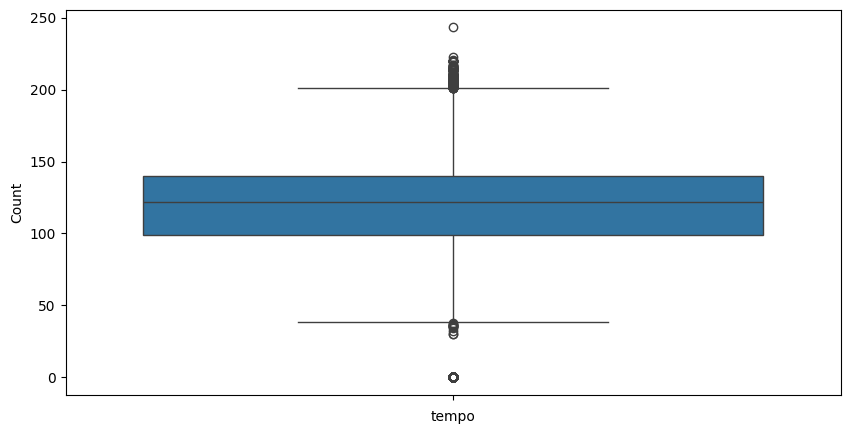

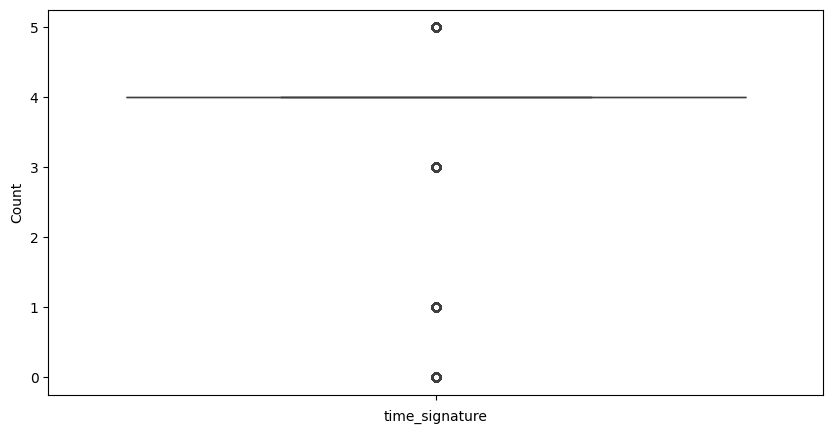

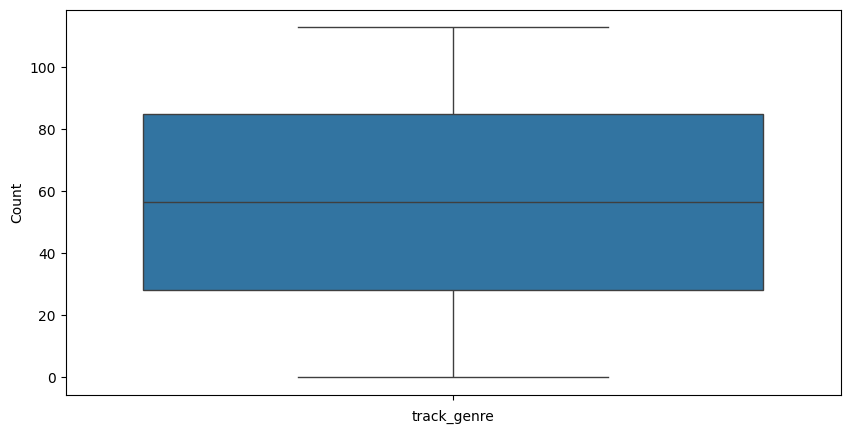

In [225]:
#now finally box plot
features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(music_dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

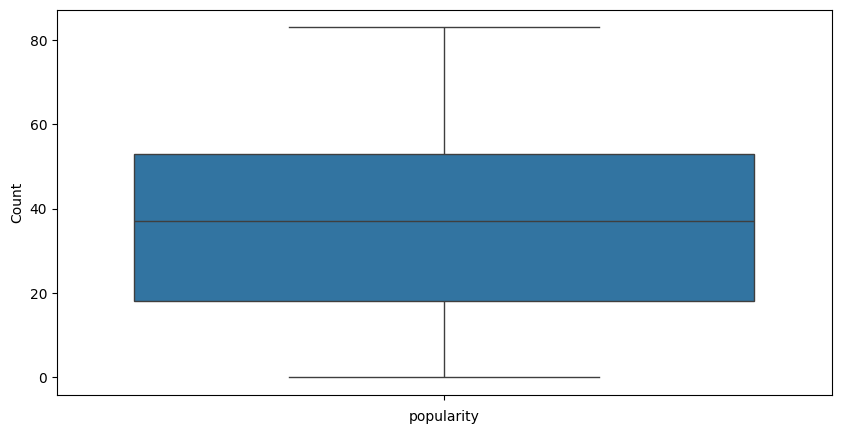

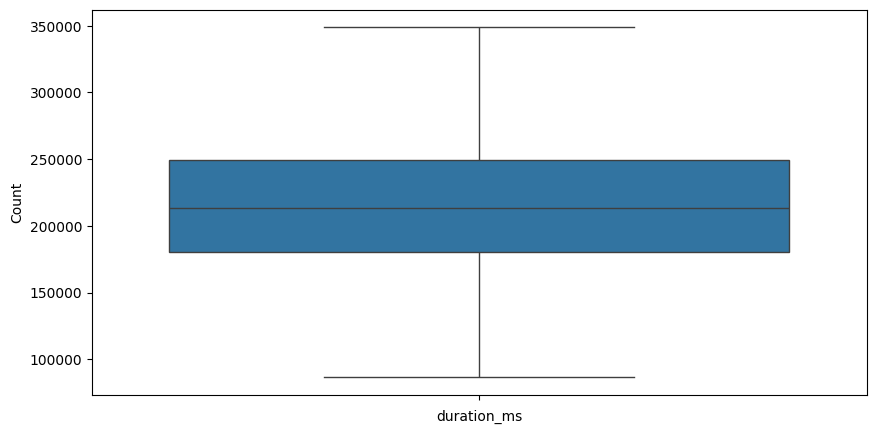

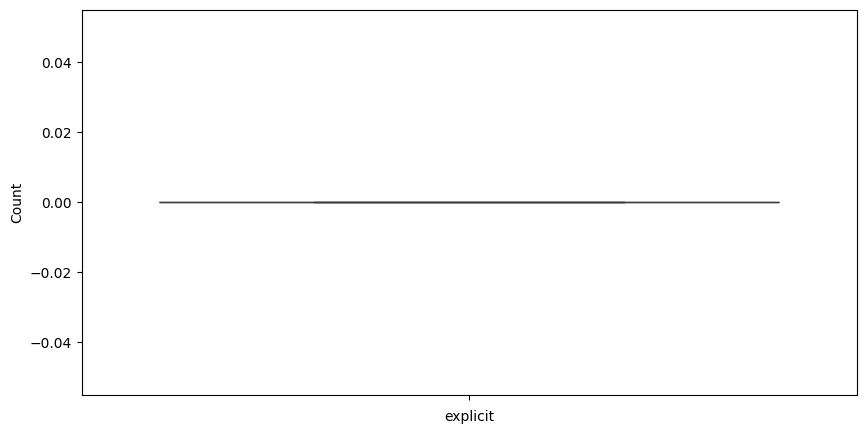

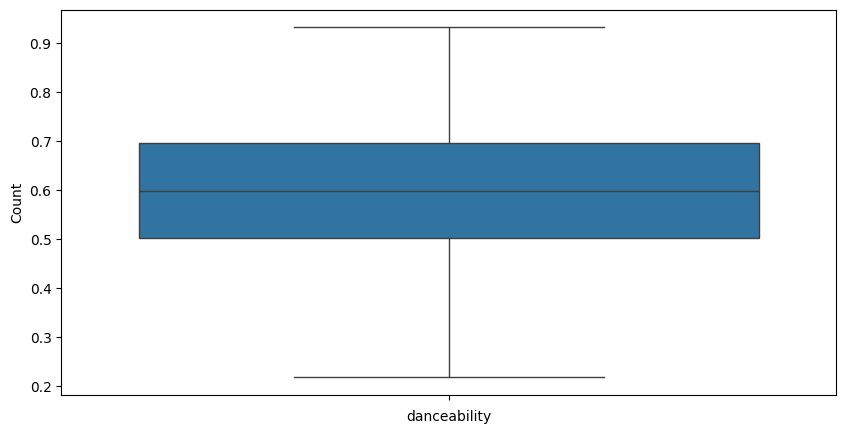

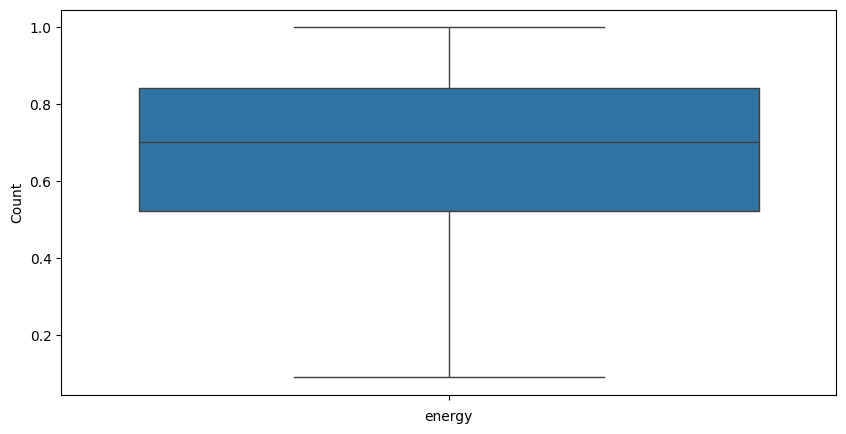

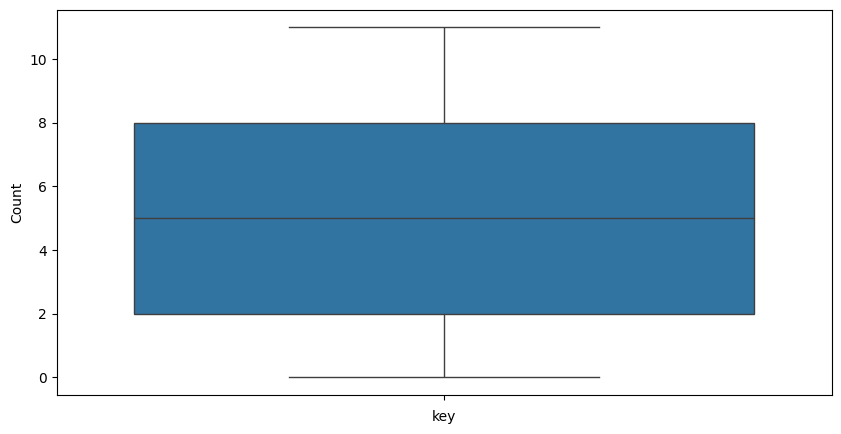

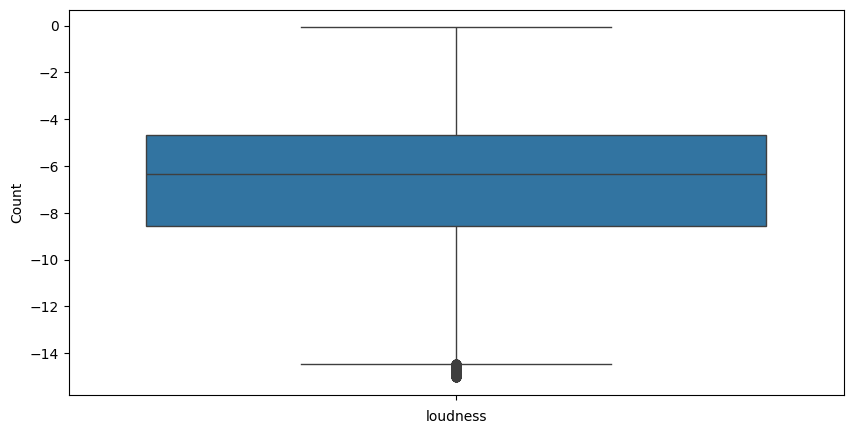

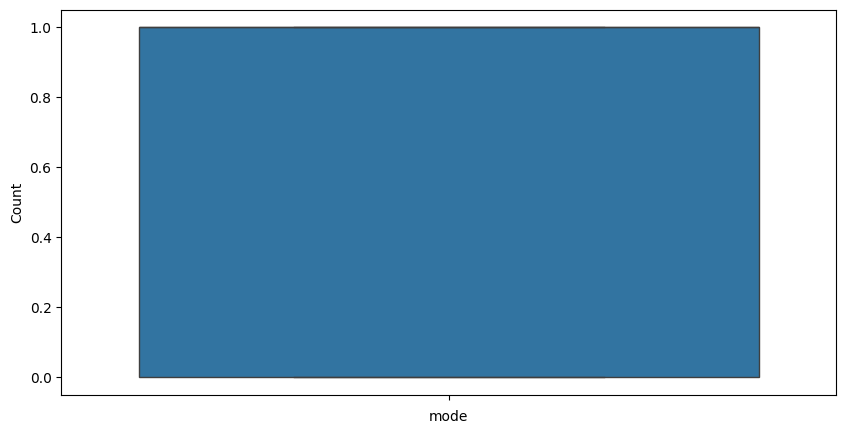

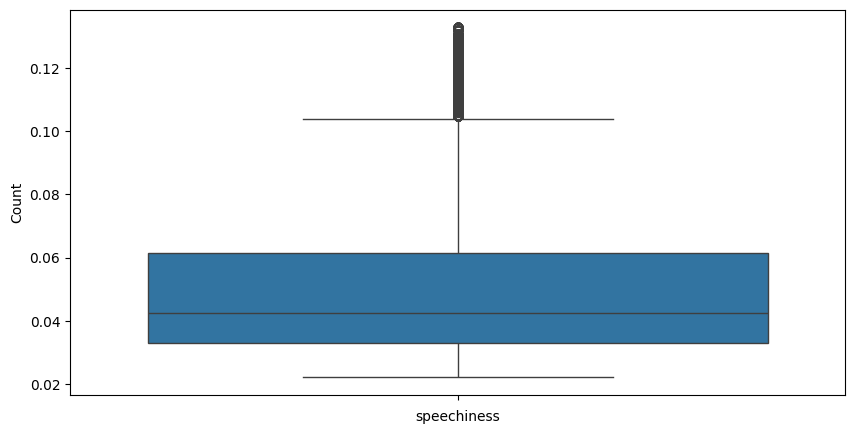

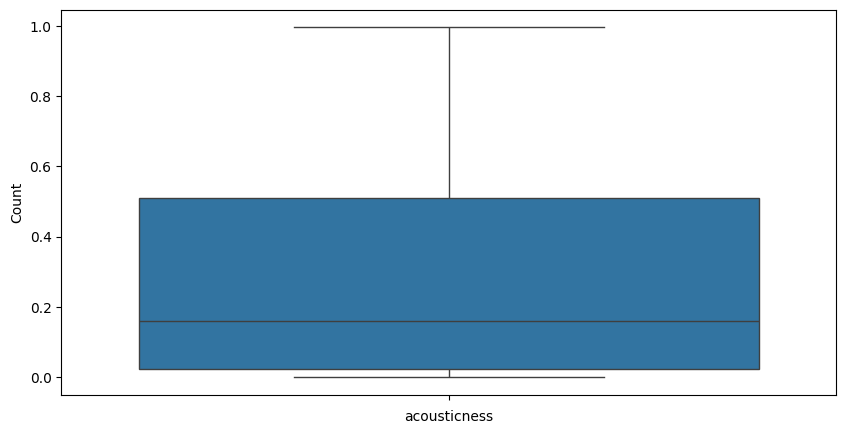

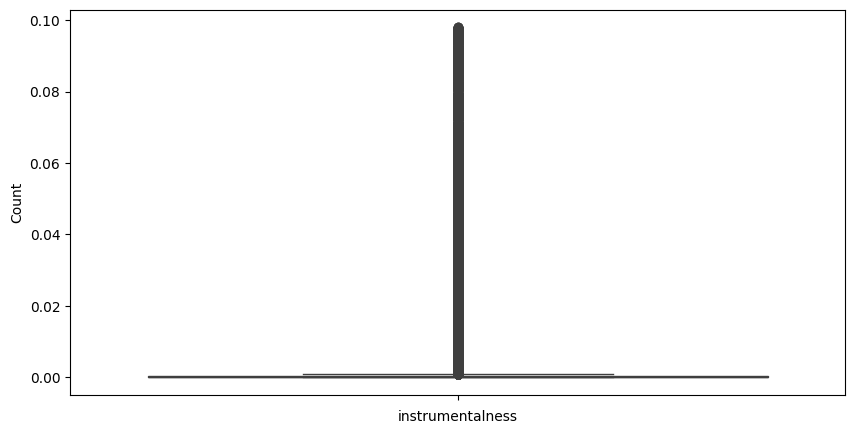

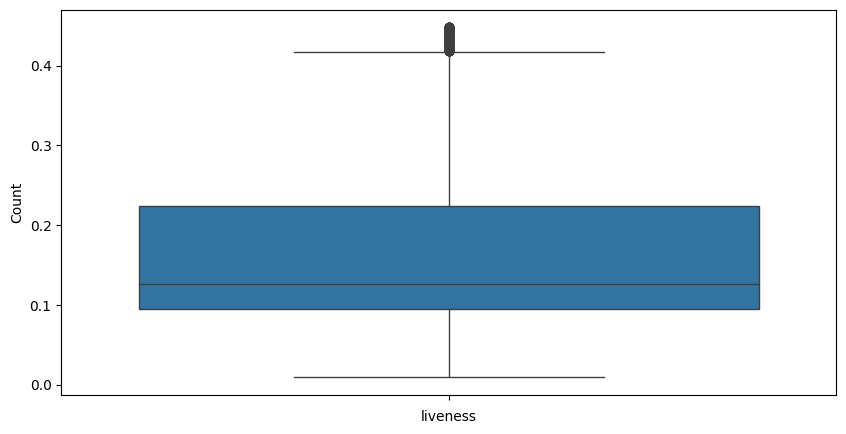

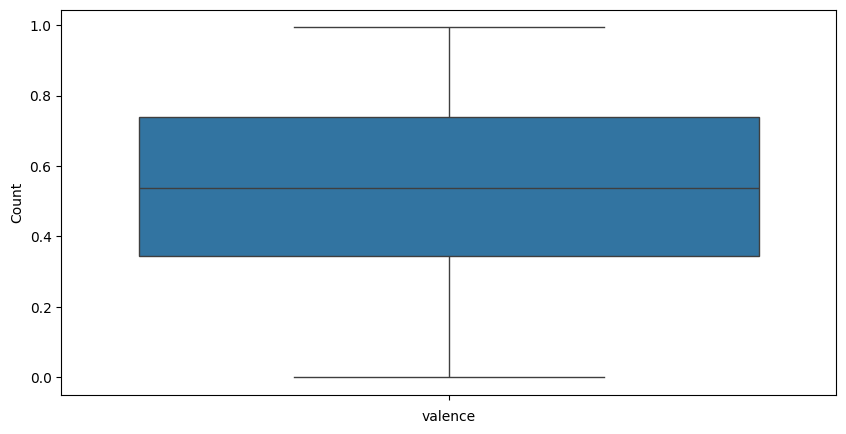

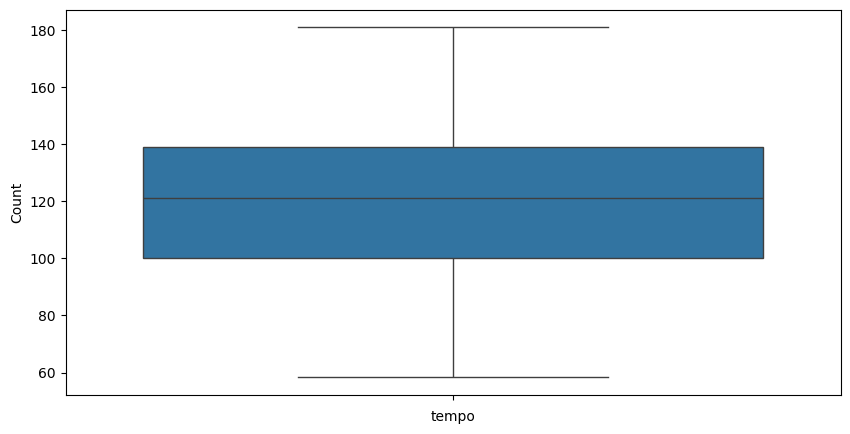

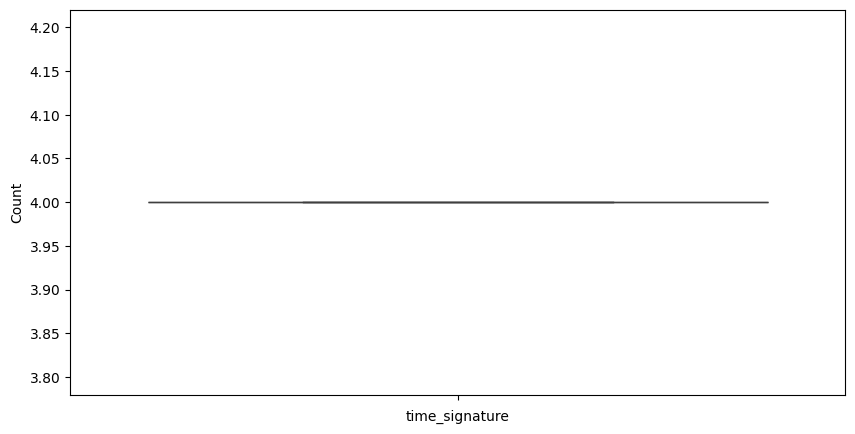

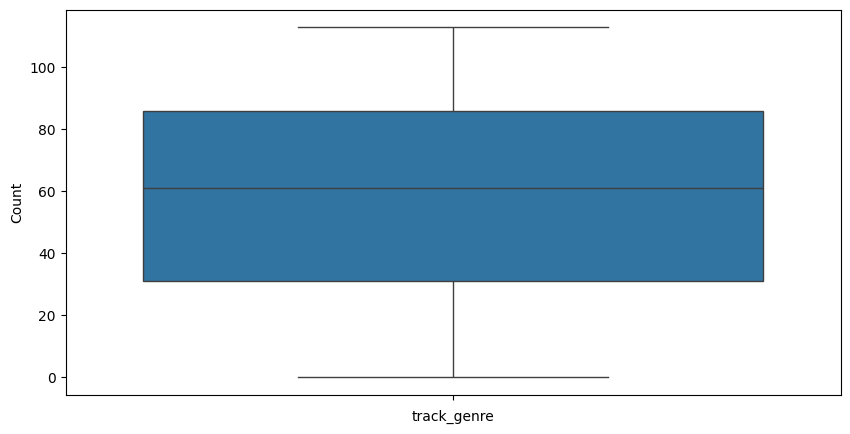

In [226]:
#remove outliers
Q1 = music_dataset.quantile(0.25)
Q3 = music_dataset.quantile(0.75)
IQR = Q3 - Q1
music_dataset = music_dataset[~((music_dataset < (Q1 - 1.0 * IQR)) | (music_dataset > (Q3 + 1.0 * IQR))).any(axis=1)]

features = music_dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(music_dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [227]:
#correlation matrix
correlationMatrix = music_dataset.corr()
correlationMatrix

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
popularity,1.000000,0.090970,NaN,-0.037887,-0.017512,0.000671,-0.000834,-0.022729,-0.041234,-0.010865,0.000724,-0.017577,-0.120491,0.033117,NaN,-0.003232
duration_ms,0.090970,1.000000,NaN,-0.164171,0.058525,0.007921,0.029586,-0.032562,-0.107496,-0.086835,0.046848,-0.047497,-0.201853,0.024416,NaN,-0.006337
explicit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,-0.037887,-0.164171,NaN,1.000000,0.031440,0.018160,0.039851,-0.078701,0.101932,-0.044315,-0.001500,-0.096530,0.447255,-0.144935,NaN,-0.001782
energy,-0.017512,0.058525,NaN,0.031440,1.000000,0.032249,0.739877,-0.113047,0.327623,-0.704532,0.057831,0.163253,0.263651,0.214702,NaN,-0.025763
key,0.000671,0.007921,NaN,0.018160,0.032249,1.000000,0.022710,-0.107123,0.043453,-0.033023,0.009931,-0.012915,0.027554,0.004619,NaN,-0.006672
loudness,-0.000834,0.029586,NaN,0.039851,0.739877,0.022710,1.000000,-0.083637,0.228631,-0.513839,-0.053252,0.114524,0.107258,0.143835,NaN,-0.050700
mode,-0.022729,-0.032562,NaN,-0.078701,-0.113047,-0.107123,-0.083637,1.000000,-0.105079,0.114398,-0.049289,-0.001301,0.018216,-0.005532,NaN,0.002086
speechiness,-0.041234,-0.107496,NaN,0.101932,0.327623,0.043453,0.228631,-0.105079,1.000000,-0.214381,0.005830,0.063812,0.077930,0.102073,NaN,-0.003514
acousticness,-0.010865,-0.086835,NaN,-0.044315,-0.704532,-0.033023,-0.513839,0.114398,-0.214381,1.000000,-0.065469,-0.069253,-0.064823,-0.162603,NaN,0.076373


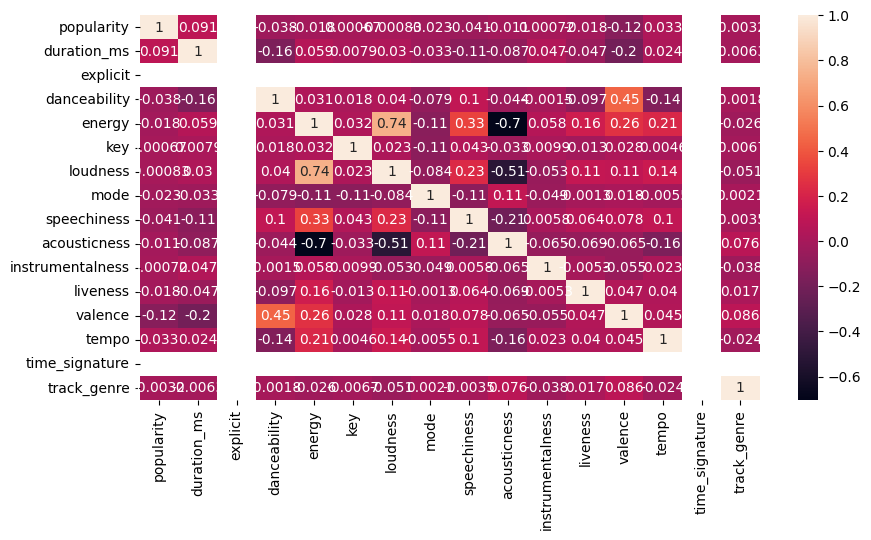

In [228]:
plt.figure(figsize=(10, 5))
sns.heatmap(correlationMatrix, annot=True)
plt.show()

In [229]:
#constant features
features = music_dataset.columns
for feature in features:
    if music_dataset[feature].std() == 0:
        print(feature)
        print(music_dataset[feature].std())
        print('\n')

explicit
0.0


time_signature
0.0




In [230]:
print("Unique time_signature values:", music_dataset['time_signature'].unique())
print("Unique explicit values:", music_dataset['explicit'].unique())

Unique time_signature values: [4]
Unique explicit values: [0]


In [231]:
#remove these useless constant features 
music_dataset.drop(['explicit', 'time_signature'], axis = 1, inplace = True)
music_dataset

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_29602/1547370975.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
2,57,210826,0.438,0.359,0,-9.734,1,0.0557,0.21000,0.000000,0.1170,0.120,76.332,0
4,82,198853,0.618,0.443,2,-9.681,1,0.0526,0.46900,0.000000,0.0829,0.167,119.949,0
5,58,214240,0.688,0.481,6,-8.807,1,0.1050,0.28900,0.000000,0.1890,0.666,98.017,0
7,80,242946,0.703,0.444,11,-9.331,1,0.0417,0.55900,0.000000,0.0973,0.712,150.960,0
8,74,189613,0.625,0.414,0,-8.700,1,0.0369,0.29400,0.000000,0.1510,0.669,130.088,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113991,32,250629,0.387,0.531,8,-4.788,1,0.0290,0.00305,0.000000,0.2010,0.153,146.003,113
113992,38,312566,0.475,0.860,10,-4.722,1,0.0421,0.00650,0.000002,0.2460,0.427,113.949,113
113997,22,271466,0.629,0.329,0,-10.895,0,0.0420,0.86700,0.000000,0.0839,0.743,132.378,113
113998,41,283893,0.587,0.506,7,-10.889,1,0.0297,0.38100,0.000000,0.2700,0.413,135.960,113


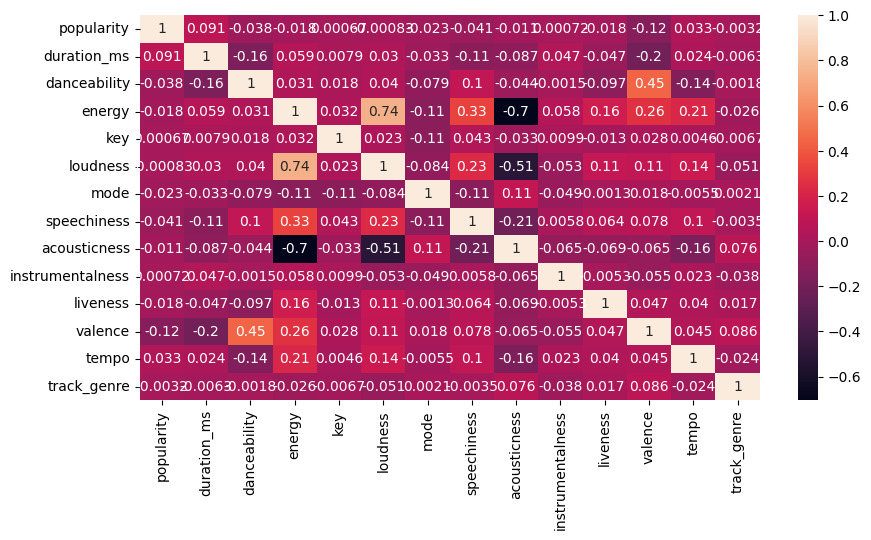

In [232]:
correlationMatrix2 = music_dataset.corr()

plt.figure(figsize=(10, 5))
sns.heatmap(correlationMatrix2, annot=True)
plt.show()

Training the Model 💪🏋️

1. Logistic Regression

In [233]:
X1 = music_dataset.drop('track_genre', axis = 1)
Y1 = music_dataset['track_genre']

X1_train1, X1_test1, Y1_train1, Y1_test1 = train_test_split(X1, Y1, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X1_train1 = scaler.fit_transform(X1_train1)
X1_test1 = scaler.transform(X1_test1)

In [234]:
music_dataset

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
2,57,210826,0.438,0.359,0,-9.734,1,0.0557,0.21000,0.000000,0.1170,0.120,76.332,0
4,82,198853,0.618,0.443,2,-9.681,1,0.0526,0.46900,0.000000,0.0829,0.167,119.949,0
5,58,214240,0.688,0.481,6,-8.807,1,0.1050,0.28900,0.000000,0.1890,0.666,98.017,0
7,80,242946,0.703,0.444,11,-9.331,1,0.0417,0.55900,0.000000,0.0973,0.712,150.960,0
8,74,189613,0.625,0.414,0,-8.700,1,0.0369,0.29400,0.000000,0.1510,0.669,130.088,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113991,32,250629,0.387,0.531,8,-4.788,1,0.0290,0.00305,0.000000,0.2010,0.153,146.003,113
113992,38,312566,0.475,0.860,10,-4.722,1,0.0421,0.00650,0.000002,0.2460,0.427,113.949,113
113997,22,271466,0.629,0.329,0,-10.895,0,0.0420,0.86700,0.000000,0.0839,0.743,132.378,113
113998,41,283893,0.587,0.506,7,-10.889,1,0.0297,0.38100,0.000000,0.2700,0.413,135.960,113


In [235]:
model1 = LogisticRegression()
model1.fit(X1_train1, Y1_train1)

LogisticRegression()

In [236]:
#print actual values and predicted values 
actual_values1 = Y1_test1
predicted_values1 = model1.predict(X1_test1)

print("Actual values:", actual_values1)
print("Predicted values:", predicted_values1)

Actual values: 90990    91
34703    34
60904    60
87445    87
39773    39
         ..
44819    44
88300    88
38511    38
16606    16
82528    82
Name: track_genre, Length: 10181, dtype: int64
Predicted values: [76 80 51 ... 50 70 78]


In [ ]:
#evaluation metrics 
accuracy1 = accuracy_score(Y1_test1, predicted_values1)
precision1 = precision_score(Y1_test1, predicted_values1, average='macro')
recall1 = recall_score(Y1_test1, predicted_values1, average='macro')
f1_score1 = f1_score(Y1_test1, predicted_values1, average='macro')

print("Accuracy:", accuracy1 * 100)
print("Precision:", precision1 * 100)
print("Recall:", recall1 * 100)
print("F1 Score:", f1_score1 * 100)

Accuracy: 15.695904135153718
Precision: 12.054125446017053
Recall: 13.798575630332333
F1 Score: 11.43170562565554


/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [238]:
#classification report 
print(classification_report(Y1_test1, predicted_values1))

              precision    recall  f1-score   support

           0       0.13      0.12      0.13       136
           1       0.06      0.01      0.02        74
           2       0.04      0.01      0.01       137
           3       0.00      0.00      0.00       100
           4       0.17      0.04      0.07        23
           5       0.10      0.09      0.10        86
           6       0.33      0.05      0.08        21
           7       0.20      0.20      0.20       122
           8       0.00      0.00      0.00       121
           9       0.00      0.00      0.00        88
          10       0.15      0.16      0.16        31
          11       0.00      0.00      0.00        90
          12       0.13      0.18      0.15       153
          13       0.13      0.20      0.16        30
          14       0.26      0.35      0.30       103
          15       0.11      0.19      0.14        77
          16       0.00      0.00      0.00        13
          17       0.00    

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [239]:
import plotly.express as px
import plotly.io as pio

cm = confusion_matrix(Y1_test1, predicted_values1)
fig1 = px.imshow(cm, labels = dict(x = "Predicted", y = "Actual", color = "magma"), text_auto = True)
fig1.update_layout(width = 3000, height = 2500)
pio.renderers.default = 'browser'
fig1.show()

2. Decision Tree

In [240]:
X2 = music_dataset.drop('track_genre', axis = 1)
Y2 = music_dataset['track_genre']

X2_train2, X2_test2, Y2_train2, Y2_test2 = train_test_split(X2, Y2, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X2_train2 = scaler.fit_transform(X2_train2)
X2_test2 = scaler.transform(X2_test2)

In [241]:
#hyoerparameter tuning 
param_grid = {'max_depth': [3, 5, 10], 'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random']}

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X2_train2, Y2_train2)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'splitter': 'best'}
Best score: 0.19190625222363328


In [263]:
model2 = DecisionTreeClassifier(max_depth = 10, criterion = 'entropy', splitter = 'best')
model2.fit(X2_train2, Y2_train2)

DecisionTreeClassifier(criterion='entropy', max_depth=10)

In [243]:
#actual values vs predicted values 
actual_values2 = Y2_test2
predicted_values2 = model2.predict(X2_test2)

print("Actual values:", actual_values2)
print("Predicted values:", predicted_values2)

Actual values: 90990    91
34703    34
60904    60
87445    87
39773    39
         ..
44819    44
88300    88
38511    38
16606    16
82528    82
Name: track_genre, Length: 10181, dtype: int64
Predicted values: [16 26  5 ... 41  7 78]


In [244]:
#evaluation metrics 
accuracy2 = accuracy_score(Y2_test2, predicted_values2)
precision2 = precision_score(Y2_test2, predicted_values2, average='macro')
recall2 = recall_score(Y2_test2, predicted_values2, average='macro')
f1_score2 = f1_score(Y2_test2, predicted_values2, average='macro')

print("Accuracy:", accuracy2 * 100)
print("Precision:", precision2 * 100)
print("Recall:", recall2 * 100)
print("F1 Score:", f1_score2 * 100)

Accuracy: 19.153324820744526
Precision: 17.539974172446033
Recall: 17.301234447766515
F1 Score: 16.313693308169945


/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [245]:
#classification report 
print(classification_report(Y2_test2, predicted_values2))

              precision    recall  f1-score   support

           0       0.14      0.21      0.16       136
           1       0.16      0.19      0.17        74
           2       0.07      0.09      0.08       137
           3       0.08      0.06      0.07       100
           4       0.00      0.00      0.00        23
           5       0.15      0.22      0.18        86
           6       0.20      0.05      0.08        21
           7       0.32      0.48      0.38       122
           8       0.08      0.05      0.06       121
           9       0.10      0.14      0.11        88
          10       0.24      0.23      0.23        31
          11       0.10      0.04      0.06        90
          12       0.14      0.15      0.14       153
          13       0.33      0.27      0.30        30
          14       0.18      0.18      0.18       103
          15       0.15      0.22      0.18        77
          16       0.00      0.00      0.00        13
          17       0.00    

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [246]:
#confusion matrix

cm = confusion_matrix(Y2_test2, predicted_values2)
fig2 = px.imshow(cm, labels = dict(x = "Predicted", y = "Actual", color = "magma"), text_auto = True)
fig2.update_layout(width = 3000, height = 2500)
pio.renderers.default = 'browser'
fig2.show()

3. Naive Bayes

In [247]:
X3 = music_dataset.drop('track_genre', axis = 1)
Y3 = music_dataset['track_genre']

X3_train3, X3_test3, Y3_train3, Y3_test3 = train_test_split(X3, Y3, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X3_train3 = scaler.fit_transform(X3_train3)
X3_test3 = scaler.transform(X3_test3)

In [248]:
#hyperparameter tuning for naive bayes
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

grid_search = GridSearchCV(GaussianNB(), param_grid, cv=5)
grid_search.fit(X3_train3, Y3_train3)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'var_smoothing': 1e-09}
Best score: 0.139307034460135


In [249]:
model3 = GaussianNB(var_smoothing = 1e-09)
model3.fit(X3_train3, Y3_train3)

GaussianNB()

In [250]:
#actual values vs predicted values 
actual_values3 = Y3_test3
predicted_values3 = model3.predict(X3_test3)

print("Actual values:", actual_values3)
print("Predicted values:", predicted_values3)

Actual values: 90990    91
34703    34
60904    60
87445    87
39773    39
         ..
44819    44
88300    88
38511    38
16606    16
82528    82
Name: track_genre, Length: 10181, dtype: int64
Predicted values: [ 76 112  97 ...  50  70  78]


In [251]:
#evaluation metrics 
accuracy3 = accuracy_score(Y3_test3, predicted_values3)
precision3 = precision_score(Y3_test3, predicted_values3, average='macro')
recall3 = recall_score(Y3_test3, predicted_values3, average='macro')
f1_score3 = f1_score(Y3_test3, predicted_values3, average='macro')

print("Accuracy:", accuracy3 * 100)
print("Precision:", precision3 * 100)
print("Recall:", recall3 * 100)
print("F1 Score:", f1_score3 * 100)

Accuracy: 14.212749238778116
Precision: 12.892049761481081
Recall: 14.879853361079212
F1 Score: 10.820438391646343


/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [252]:
#classification report 
print(classification_report(Y3_test3, predicted_values3))

              precision    recall  f1-score   support

           0       0.17      0.17      0.17       136
           1       0.07      0.01      0.02        74
           2       0.00      0.00      0.00       137
           3       0.00      0.00      0.00       100
           4       0.02      0.04      0.03        23
           5       0.06      0.09      0.07        86
           6       0.00      0.00      0.00        21
           7       0.39      0.13      0.20       122
           8       0.00      0.00      0.00       121
           9       0.00      0.00      0.00        88
          10       0.11      0.16      0.13        31
          11       0.33      0.01      0.02        90
          12       0.12      0.23      0.16       153
          13       0.13      0.37      0.19        30
          14       0.37      0.18      0.25       103
          15       0.16      0.12      0.14        77
          16       0.00      0.00      0.00        13
          17       0.00    

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [253]:
#confusion matrix

cm = confusion_matrix(Y3_test3, predicted_values3)
fig3 = px.imshow(cm, labels = dict(x = "Predicted", y = "Actual", color = "magma"), text_auto = True)
fig3.update_layout(width = 3000, height = 2500)
pio.renderers.default = 'browser'
fig3.show()

4. KNN 

In [254]:
X4 = music_dataset.drop('track_genre', axis = 1)    
Y4 = music_dataset['track_genre']

X4_train4, X4_test4, Y4_train4, Y4_test4 = train_test_split(X4, Y4, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X4_train4 = scaler.fit_transform(X4_train4)
X4_test4 = scaler.transform(X4_test4)

In [255]:
#hyperparameter tuning for knn
param_grid = {'n_neighbors': [3, 5, 10], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan', 'minkowski']}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X4_train4, Y4_train4)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Best score: 0.19153787684177137


In [256]:
model4 = KNeighborsClassifier(n_neighbors = 3, weights = 'uniform', metric = 'euclidean')
model4.fit(X4_train4, Y4_train4)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [257]:
#actual values vs predicted values 
actual_values4 = Y4_test4
predicted_values4 = model4.predict(X4_test4)

print("Actual values:", actual_values4)
print("Predicted values:", predicted_values4)

Actual values: 90990    91
34703    34
60904    60
87445    87
39773    39
         ..
44819    44
88300    88
38511    38
16606    16
82528    82
Name: track_genre, Length: 10181, dtype: int64
Predicted values: [ 0 76 17 ... 40  7 35]


In [258]:
#evaluation metrics 
accuracy4 = accuracy_score(Y4_test4, predicted_values4)
precision4 = precision_score(Y4_test4, predicted_values4, average='macro')
recall4 = recall_score(Y4_test4, predicted_values4, average='macro')
f1_score4 = f1_score(Y4_test4, predicted_values4, average='macro')

print("Accuracy:", accuracy4 * 100)
print("Precision:", precision4 * 100)
print("Recall:", recall4 * 100)
print("F1 Score:", f1_score4 * 100)

Accuracy: 14.635104606620175
Precision: 15.74861594721251
Recall: 13.168914091494102
F1 Score: 12.915924940514802


/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [259]:
#classification report 
print(classification_report(Y4_test4, predicted_values4))

              precision    recall  f1-score   support

           0       0.09      0.24      0.13       136
           1       0.08      0.18      0.11        74
           2       0.07      0.18      0.10       137
           3       0.06      0.10      0.08       100
           4       0.00      0.00      0.00        23
           5       0.07      0.19      0.10        86
           6       0.09      0.19      0.12        21
           7       0.16      0.35      0.22       122
           8       0.10      0.20      0.14       121
           9       0.03      0.07      0.04        88
          10       0.09      0.16      0.11        31
          11       0.08      0.18      0.11        90
          12       0.13      0.26      0.17       153
          13       0.03      0.03      0.03        30
          14       0.22      0.29      0.25       103
          15       0.12      0.19      0.15        77
          16       0.00      0.00      0.00        13
          17       0.05    

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [260]:
#confusion matrix

cm = confusion_matrix(Y4_test4, predicted_values4)
fig4 = px.imshow(cm, labels = dict(x = "Predicted", y = "Actual", color = "magma"), text_auto = True)
fig4.update_layout(width = 3000, height = 2500)
pio.renderers.default = 'browser'
fig4.show()

5. Random Forest

In [261]:
X5 = music_dataset.drop('track_genre', axis = 1)    
Y5 = music_dataset['track_genre']

X5_train5, X5_test5, Y5_train5, Y5_test5 = train_test_split(X5, Y5, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X5_train5 = scaler.fit_transform(X5_train5)
X5_test5 = scaler.transform(X5_test5)

In [262]:
#hyperparameter tuning for Random Forest
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X5_train5, Y5_train5)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

KeyboardInterrupt: 

In [210]:
model5 = RandomForestClassifier(n_estimators = 100, max_depth = None, min_samples_split = 2)
model5.fit(X5_train5, Y5_train5)

KeyboardInterrupt: 

In [ ]:
#actual values vs predicted values 
actual_values5 = Y5_test5
predicted_values5 = model5.predict(X5_test5)

print("Actual values:", actual_values5)
print("Predicted values:", predicted_values5)

In [ ]:
#evaluation metrics 
accuracy5 = accuracy_score(Y5_test5, predicted_values5)
precision5 = precision_score(Y5_test5, predicted_values5, average='macro')
recall5 = recall_score(Y5_test5, predicted_values5, average='macro')
f1_score5 = f1_score(Y5_test5, predicted_values5, average='macro')

print("Accuracy:", accuracy5 * 100)
print("Precision:", precision5 * 100)
print("Recall:", recall5 * 100)
print("F1 Score:", f1_score5 * 100)

In [ ]:
#classification report 
print(classification_report(Y5_test5, predicted_values5))

In [ ]:
#confusion matrix

cm = confusion_matrix(Y5_test5, predicted_values5)
fig5 = px.imshow(cm, labels = dict(x = "Predicted", y = "Actual", color = "magma"), text_auto = True)
fig5.update_layout(width = 3000, height = 2500)
pio.renderers.default = 'browser'
fig5.show()

6. LightGBM

In [267]:
X6 = music_dataset.drop('track_genre', axis = 1)    
Y6 = music_dataset['track_genre']

X6_train6, X6_test6, Y6_train6, Y6_test6 = train_test_split(X6, Y6, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X6_train6 = scaler.fit_transform(X6_train6)
X6_test6 = scaler.transform(X6_test6)

In [ ]:
#hyperparameter tuning for LightGBM
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 6, 9], 'learning_rate': [0.1, 0.01, 0.001]}

grid_search = GridSearchCV(lgb.LGBMClassifier(), param_grid, cv=5)
grid_search.fit(X6_train6, Y6_train6)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

In [268]:
model6 = lgb.LGBMClassifier(n_estimators = 100, max_depth = 3, learning_rate = 0.1)
model6.fit(X6_train6, Y6_train6)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000616 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2650
[LightGBM] [Info] Number of data points in the train set: 40723, number of used features: 13
[LightGBM] [Info] Start training from score -4.321129
[LightGBM] [Info] Start training from score -4.990531
[LightGBM] [Info] Start training from score -4.354967
[LightGBM] [Info] Start training from score -4.492056
[LightGBM] [Info] Start training from score -6.455665
[LightGBM] [Info] Start training from score -4.797437
[LightGBM] [Info] Start training from score -6.195708
[LightGBM] [Info] Start training from score -4.509755
[LightGBM] [Info] Start training from score -4.440762
[LightGBM] [Info] Start training from score -4.785603
[LightGBM] [Info] Start training from score -5.564692
[LightGBM] [Info] Start training from score -4.666513

LGBMClassifier(max_depth=3)

In [269]:
#actual values vs predicted values 
actual_values6 = Y6_test6
predicted_values6 = model6.predict(X6_test6)

print("Actual values:", actual_values6)
print("Predicted values:", predicted_values6)

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Actual values: 90990    91
34703    34
60904    60
87445    87
39773    39
         ..
44819    44
88300    88
38511    38
16606    16
82528    82
Name: track_genre, Length: 10181, dtype: int64
Predicted values: [76 69  9 ... 49 14 78]


In [270]:
#evaluation metrics 
accuracy6 = accuracy_score(Y6_test6, predicted_values6)
precision6 = precision_score(Y6_test6, predicted_values6, average='macro')
recall6 = recall_score(Y6_test6, predicted_values6, average='macro')
f1_score6 = f1_score(Y6_test6, predicted_values6, average='macro')

print("Accuracy:", accuracy6 * 100)
print("Precision:", precision6 * 100)
print("Recall:", recall6 * 100)
print("F1 Score:", f1_score6 * 100)

Accuracy: 25.174344366958056
Precision: 23.010669625895254
Recall: 23.65846131800805
F1 Score: 22.521463233511447


In [271]:
#classification report 
print(classification_report(Y6_test6, predicted_values6))

              precision    recall  f1-score   support

           0       0.24      0.20      0.22       136
           1       0.25      0.18      0.21        74
           2       0.12      0.09      0.10       137
           3       0.04      0.03      0.03       100
           4       0.00      0.00      0.00        23
           5       0.17      0.19      0.18        86
           6       0.15      0.19      0.17        21
           7       0.41      0.52      0.46       122
           8       0.27      0.14      0.19       121
           9       0.06      0.08      0.07        88
          10       0.29      0.32      0.31        31
          11       0.10      0.06      0.07        90
          12       0.26      0.25      0.26       153
          13       0.37      0.47      0.41        30
          14       0.41      0.27      0.33       103
          15       0.19      0.23      0.21        77
          16       0.00      0.00      0.00        13
          17       0.10    

In [272]:
#confusion matrix

cm = confusion_matrix(Y6_test6, predicted_values6)
fig6 = px.imshow(cm, labels = dict(x = "Predicted", y = "Actual", color = "magma"), text_auto = True)
fig6.update_layout(width = 3000, height = 2500)
pio.renderers.default = 'browser'
fig6.show()

In [277]:
music_dataset['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow